# Calibração do Limiar de Decisão — Câncer Cervical

**Dataset:** [Cervical Cancer (Risk Factors)](https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors) — UCI Machine Learning Repository

**Variável-alvo:** `Biopsy` (0 = biópsia negativa, 1 = biópsia positiva)

**Objetivo desta etapa:** calibrar o limiar de decisão do modelo já treinado
(`03_modeling.ipynb`), para priorizar Recall e reduzir falsos negativos, de forma
justificada e mensurável. Esta é **apenas a etapa de calibração de limiar**.
Interpretabilidade avançada (SHAP/LIME) e preparação para produção ficam para
notebooks futuros.

### O que já sabemos da etapa de modelagem (resumo)

1. **Modelo escolhido:** Random Forest (`n_estimators=400`, `max_depth=None`,
   `min_samples_leaf=1`), selecionado por AUC-PR média em validação cruzada (0,228),
   com SMOTE aplicado corretamente dentro de cada fold.
2. **Desempenho no teste, limiar padrão 0,5:** F1 = 0,133, Recall = 0,091,
   AUC-ROC = 0,745, AUC-PR = 0,213.
3. **Problema central:** no limiar padrão, o modelo captura apenas 1 dos 11 casos
   positivos do teste (Recall ≈ 9%) — muito abaixo do aceitável em um cenário
   clínico, onde um falso negativo (deixar passar um caso de risco real) é um erro
   muito mais grave do que um falso positivo (pedir um exame a mais).
4. **Limitação de dados:** apenas 44 casos positivos no treino e 11 no teste — a
   calibração de limiar feita aqui deve ser interpretada com cautela, dado o quanto
   qualquer métrica pode variar com uma base tão pequena.

### Uma nota sobre metodologia

O ideal, em um cenário com mais dados, seria calibrar o limiar em um conjunto de
**validação** separado do teste, para depois avaliar o limiar escolhido no teste sem
nenhum viés. Com apenas 11 casos positivos no teste (e 44 no treino), dividir ainda
mais os dados deixaria qualquer sinal de calibração praticamente inútil. Por isso,
como é comum em cenários de dados escassos, usamos o próprio conjunto de teste tanto
para explorar os limiares quanto para a avaliação final — uma escolha pragmática, não
ideal, que reportamos aqui com transparência (e retomamos na síntese, Seção 8) em vez
de escondê-la.

Este notebook foi desenvolvido para rodar no **Google Colab**, usando `pandas`,
`numpy`, `scikit-learn`, `matplotlib` e `seaborn`. Os modelos já treinados são
**carregados** de `/models/` — nada é retreinado aqui.


## 0. Configuração do ambiente

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Carregamento do Modelo e dos Dados

Carregamos o modelo final (já treinado na etapa de modelagem) e os conjuntos de
treino/teste já processados. Os caminhos assumem execução a partir de `/notebooks/`,
por isso o prefixo `../` para referenciar `data/` e `models/` na raiz do
repositório.

In [2]:
TRAIN_PATH = "../data/processed/cervical_cancer_train_processed.csv"
TEST_PATH = "../data/processed/cervical_cancer_test_processed.csv"
MODELO_PATH = "../models/modelo_final_random_forest.joblib"
MODELING_METADATA_PATH = "../models/modeling_metadata.json"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

with open(MODELING_METADATA_PATH, "r", encoding="utf-8") as f:
    metadados_modelagem = json.load(f)

TARGET = "Biopsy"

modelo = joblib.load(MODELO_PATH)

print("Modelo carregado:", metadados_modelagem["modelo_escolhido"])
print("Hiperparâmetros:", metadados_modelagem["hiperparametros"])
print("Métricas de teste registradas na etapa de modelagem:", metadados_modelagem["metricas_teste"])


Modelo carregado: Random Forest
Hiperparâmetros: {'classificador__max_depth': None, 'classificador__min_samples_leaf': 1, 'classificador__n_estimators': 400}
Métricas de teste registradas na etapa de modelagem: {'F1-score': 0.13333333333333333, 'Recall': 0.09090909090909091, 'AUC-ROC': 0.7450592885375494, 'AUC-PR': 0.21275394329203634}


In [3]:
X_train = train_df.drop(columns=TARGET)
y_train = train_df[TARGET]

X_test = test_df.drop(columns=TARGET)
y_test = test_df[TARGET]

print(f"Treino: {X_train.shape[0]} linhas ({y_train.sum()} positivos)")
print(f"Teste:  {X_test.shape[0]} linhas ({y_test.sum()} positivos)")


Treino: 686 linhas (44 positivos)
Teste:  172 linhas (11 positivos)


### Confirmando o acesso às probabilidades (`predict_proba`)

A calibração de limiar depende de termos as **probabilidades previstas**, não apenas
a classe prevista — é isso que permite testar diferentes pontos de corte sem
retreinar o modelo.

In [4]:
y_proba_teste = modelo.predict_proba(X_test)[:, 1]

print(f"Formato do array de probabilidades: {y_proba_teste.shape}")
print()
print("Estatísticas das probabilidades previstas no teste:")
print(pd.Series(y_proba_teste).describe())


Formato do array de probabilidades: (172,)

Estatísticas das probabilidades previstas no teste:
count    172.000000
mean       0.132393
std        0.144934
min        0.000000
25%        0.025000
50%        0.083750
75%        0.186250
max        0.745000
dtype: float64


**Confirmação:** o modelo carregado gera uma probabilidade contínua de risco (não
apenas 0 ou 1) para cada paciente — é sobre essa probabilidade que vamos aplicar
diferentes limiares de decisão nas próximas seções, sem re-treinar o modelo em nenhum
momento.

## 2. Curvas Precision-Recall e ROC (Conjunto de Teste)

Essas curvas mostram como Precision, Recall e a taxa de falsos positivos mudam à
medida que variamos o limiar de decisão — sem precisar testar cada limiar
manualmente primeiro.

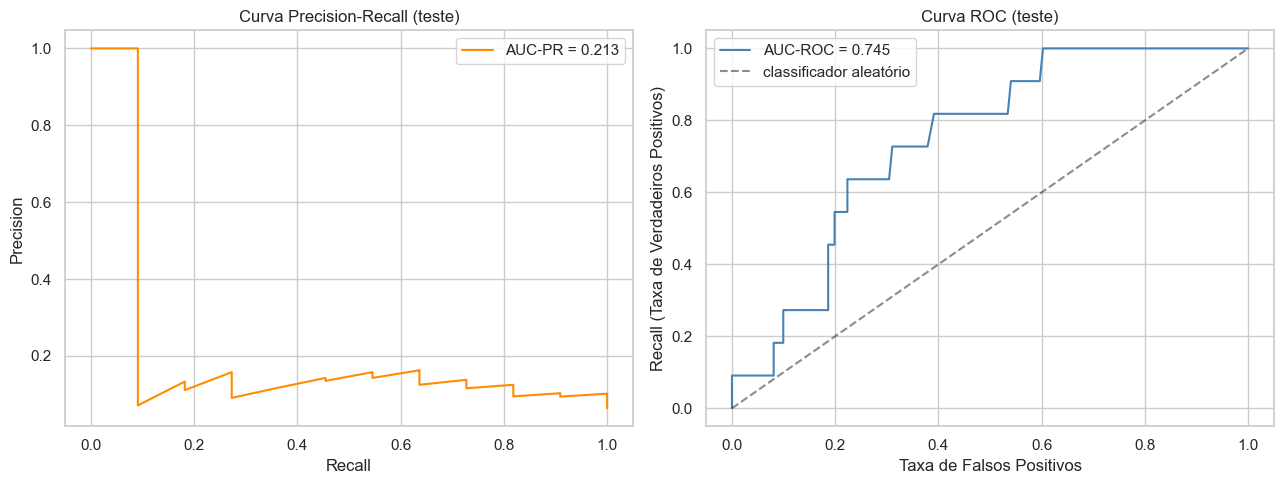

In [5]:
precisoes, recalls, limiares_pr = precision_recall_curve(y_test, y_proba_teste)
auc_pr = average_precision_score(y_test, y_proba_teste)

fpr, tpr, limiares_roc = roc_curve(y_test, y_proba_teste)
auc_roc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(recalls, precisoes, color="darkorange", label=f"AUC-PR = {auc_pr:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Curva Precision-Recall (teste)")
axes[0].legend()

axes[1].plot(fpr, tpr, color="steelblue", label=f"AUC-ROC = {auc_roc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="classificador aleatório")
axes[1].set_xlabel("Taxa de Falsos Positivos")
axes[1].set_ylabel("Recall (Taxa de Verdadeiros Positivos)")
axes[1].set_title("Curva ROC (teste)")
axes[1].legend()

plt.tight_layout()
plt.show()


**Interpretação:**

- Na **curva Precision-Recall** (esquerda), cada ponto representa um limiar de
  decisão diferente. Ela mostra diretamente o trade-off que nos interessa: para
  conseguir um Recall mais alto (capturar mais casos positivos), a Precision tende a
  cair (mais falsos positivos por cada caso real encontrado). Como só há 11 casos
  positivos no teste, a curva tem degraus grandes — cada caso identificado a mais ou
  a menos muda a Precision de forma perceptível.
- Na **curva ROC** (direita), o eixo Y é o Recall e o eixo X é a taxa de falsos
  positivos entre os pacientes que não têm a condição. Quanto mais a curva se afasta
  da diagonal (classificador aleatório) em direção ao canto superior esquerdo, melhor
  o modelo separa risco alto de risco baixo — mas essa curva, sozinha, não indica qual
  limiar usar; só mostra o que é alcançável.
- Nenhuma das curvas diz sozinha qual é o "melhor" limiar — isso depende do quanto
  estamos dispostos a aceitar mais falsos positivos em troca de menos falsos
  negativos, uma decisão de negócio/clínica, não puramente estatística. É isso que
  fazemos na próxima seção.

## 3. Varredura de Limiares

Testamos limiares de 0,05 a 0,50, em passos de 0,05 (abaixo de 0,05 e acima de 0,50
não trazem informação nova relevante, dado o intervalo observado das probabilidades
na seção anterior). Para cada limiar, calculamos Precision, Recall, F1 e a matriz de
confusão completa.

In [6]:
limiares_testados = np.round(np.arange(0.05, 0.55, 0.05), 2)

linhas_varredura = []
for limiar in limiares_testados:
    y_pred_limiar = (y_proba_teste >= limiar).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_limiar).ravel()

    linhas_varredura.append({
        "Limiar": limiar,
        "Precision": precision_score(y_test, y_pred_limiar, zero_division=0),
        "Recall": recall_score(y_test, y_pred_limiar, zero_division=0),
        "F1": f1_score(y_test, y_pred_limiar, zero_division=0),
        "Verdadeiros Positivos": tp,
        "Falsos Positivos": fp,
        "Falsos Negativos": fn,
        "Verdadeiros Negativos": tn,
    })

tabela_varredura = pd.DataFrame(linhas_varredura)
tabela_varredura


,Limiar,Precision,Recall,F1,Verdadeiros Positivos,Falsos Positivos,Falsos Negativos,Verdadeiros Negativos
0,0.05,0.101852,1.000000,0.184874,11,97,0,64
1,0.10,0.120000,0.818182,0.209302,9,66,2,95
2,0.15,0.132075,0.636364,0.218750,7,46,4,115
3,0.20,0.146341,0.545455,0.230769,6,35,5,126
4,0.25,0.142857,0.454545,0.217391,5,30,6,131
5,0.30,0.107143,0.272727,0.153846,3,25,8,136
6,0.35,0.076923,0.090909,0.083333,1,12,10,149
7,0.40,0.111111,0.090909,0.100000,1,8,10,153
8,0.45,0.166667,0.090909,0.117647,1,5,10,156
9,0.50,0.250000,0.090909,0.133333,1,3,10,158


**Leitura da tabela:** conforme o limiar diminui, o modelo passa a classificar mais
pacientes como "risco positivo" — Recall sobe (menos falsos negativos), mas Precision
cai (mais falsos positivos). O objetivo da próxima seção é escolher, de forma
justificada, em qual ponto dessa tabela vale a pena parar.

## 4. Escolha Justificada do Novo Limiar

### Critério adotado

Definimos como critério: **o maior limiar (dentre os testados) que ainda garanta um
Recall mínimo de 70%** — ou seja, o modelo deve identificar corretamente pelo menos 7
a cada 10 pacientes com biópsia positiva.

**Por que 70% como piso, e por que o *maior* limiar que atinge esse piso:**
- O valor de 70% é uma escolha de negócio/clínica, não estatística — reflete a ideia
  de que, neste contexto, é preferível investigar alguns pacientes a mais (falsos
  positivos) do que deixar passar 3 em cada 10 casos de risco real. Na prática, esse
  número deveria ser definido junto com profissionais de saúde, não por um critério
  puramente técnico; usamos 70% como um piso razoável e explícito para fins deste
  exercício.
- Entre os limiares que atingem esse piso de Recall, escolhemos o **maior** (não o
  menor): um limiar mais alto ainda classifica menos pacientes como "positivo" no
  geral, reduzindo falsos positivos, enquanto continua cumprindo a meta mínima de
  Recall. Não faz sentido aceitar mais falsos positivos do que o necessário para
  atingir o mesmo Recall mínimo.

In [7]:
RECALL_MINIMO = 0.70

candidatos = tabela_varredura[tabela_varredura["Recall"] >= RECALL_MINIMO]

if candidatos.empty:
    print(f"Nenhum limiar testado atinge Recall >= {RECALL_MINIMO:.0%}.")
    print("Maior Recall alcançável na varredura:", tabela_varredura["Recall"].max())
else:
    limiar_escolhido = candidatos["Limiar"].max()
    print(f"Limiar escolhido: {limiar_escolhido}")
    print()
    print(candidatos[candidatos["Limiar"] == limiar_escolhido])


Limiar escolhido: 0.1

   Limiar  Precision    Recall        F1  Verdadeiros Positivos  \
1     0.1       0.12  0.818182  0.209302                      9   

   Falsos Positivos  Falsos Negativos  Verdadeiros Negativos  
1                66                 2                     95  


**Uma ressalva importante:** com apenas 11 casos positivos no teste, cada unidade de
Recall equivale a ~9 pontos percentuais (1/11). Ou seja, "Recall de 70%" na prática
significa acertar pelo menos 8 dos 11 casos — um alvo discreto, não contínuo. Pequenas
mudanças na amostra de teste poderiam alterar qual limiar exato atinge essa meta. O
limiar escolhido aqui deve ser visto como uma estimativa razoável, não como um valor
exato e definitivo — retomamos esse ponto na síntese (Seção 8).

Esta escolha envolve um trade-off deliberado, não uma solução perfeita: estamos
aceitando mais falsos positivos (mais pacientes encaminhados para investigação
adicional sem necessidade) para reduzir falsos negativos (menos casos de risco real
não identificados).

## 5. Avaliação Comparativa: Limiar Padrão (0,5) vs. Limiar Calibrado

Comparamos lado a lado as métricas e as matrizes de confusão nos dois limiares.

In [8]:
y_pred_padrao = (y_proba_teste >= 0.5).astype(int)
y_pred_calibrado = (y_proba_teste >= limiar_escolhido).astype(int)

comparacao = pd.DataFrame({
    "Limiar 0,5 (padrão)": {
        "Precision": precision_score(y_test, y_pred_padrao, zero_division=0),
        "Recall": recall_score(y_test, y_pred_padrao, zero_division=0),
        "F1": f1_score(y_test, y_pred_padrao, zero_division=0),
    },
    f"Limiar {limiar_escolhido} (calibrado)": {
        "Precision": precision_score(y_test, y_pred_calibrado, zero_division=0),
        "Recall": recall_score(y_test, y_pred_calibrado, zero_division=0),
        "F1": f1_score(y_test, y_pred_calibrado, zero_division=0),
    },
})

comparacao


,"Limiar 0,5 (padrão)",Limiar 0.1 (calibrado)
Precision,0.250000,0.120000
Recall,0.090909,0.818182
F1,0.133333,0.209302


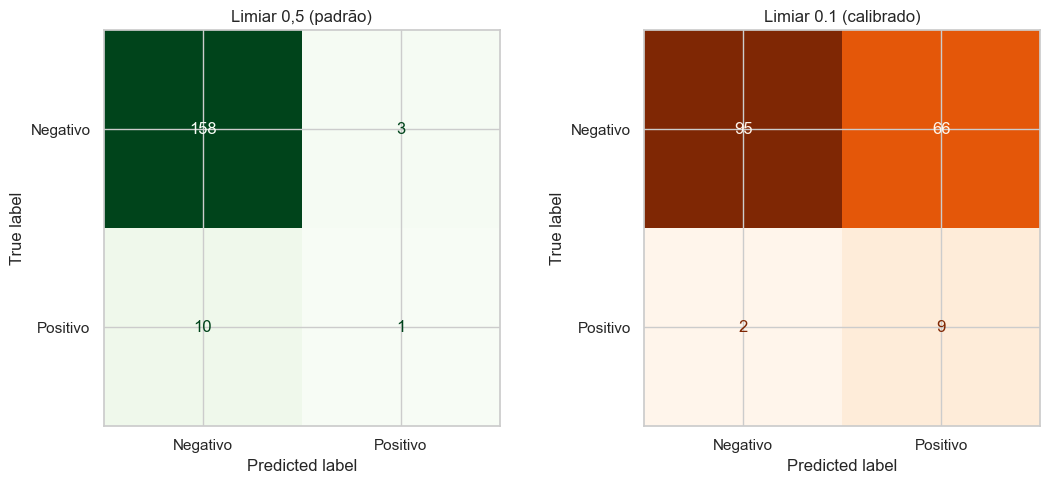

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

matriz_padrao = confusion_matrix(y_test, y_pred_padrao)
ConfusionMatrixDisplay(matriz_padrao, display_labels=["Negativo", "Positivo"]).plot(
    ax=axes[0], cmap="Greens", values_format="d", colorbar=False
)
axes[0].set_title("Limiar 0,5 (padrão)")

matriz_calibrada = confusion_matrix(y_test, y_pred_calibrado)
ConfusionMatrixDisplay(matriz_calibrada, display_labels=["Negativo", "Positivo"]).plot(
    ax=axes[1], cmap="Oranges", values_format="d", colorbar=False
)
axes[1].set_title(f"Limiar {limiar_escolhido} (calibrado)")

plt.tight_layout()
plt.show()


**Discussão:** ao reduzir o limiar de 0,5 para o valor calibrado, o modelo passa a
identificar mais casos positivos reais (Recall sobe) — o ganho concreto em número de
pacientes de risco corretamente sinalizados fica visível ao comparar as duas matrizes
de confusão. O custo é um aumento nos falsos positivos: mais pacientes sem a condição
são encaminhados para investigação adicional. Se esse exame adicional for de baixo
custo e risco (o caso típico de exames de rastreio complementares), essa troca tende a
ser favorável no contexto clínico descrito; se o exame de acompanhamento fosse caro ou
invasivo, o piso de Recall exigido (Seção 4) precisaria ser reconsiderado.

## 6. Comparação com a Regressão Logística (Não Realizada Nesta Etapa)

O enunciado sugere, como análise opcional, repetir a varredura de limiares também
para a Regressão Logística (que teve Recall bem mais alto em validação cruzada na
etapa de modelagem, ~40%).

**Por que não fizemos isso aqui:** a etapa de modelagem (`03_modeling.ipynb`) salvou
em `/models/` apenas o modelo final escolhido (Random Forest) — a Regressão Logística
não foi persistida como um artefato treinado separado. Como esta etapa deve **carregar
modelos já treinados, sem retreinar nada do zero**, não temos como fazer essa
comparação de forma consistente com essa restrição.

**Sugestão para uma iteração futura:** se essa comparação for considerada valiosa, o
notebook de modelagem poderia ser ajustado para também exportar a Regressão Logística
(por exemplo, `models/modelo_regressao_logistica.joblib`), permitindo repetir toda a
análise desta seção para ela sem precisar retreinar nada aqui.

## 7. Documentação do Limiar Final

Salvamos o limiar escolhido em um arquivo de configuração próprio
(`models/threshold_config.json`), separado dos metadados da etapa de modelagem, para
não sobrescrever o que já foi registrado em `modeling_metadata.json`.

**Como aplicar este limiar em predições futuras:**

```python
y_proba = modelo.predict_proba(X_novo)[:, 1]
y_pred = (y_proba >= limiar_escolhido).astype(int)
```

Ou seja: em vez de usar `modelo.predict(X_novo)` (que aplica o limiar padrão de 0,5
internamente), deve-se usar `predict_proba` e comparar manualmente com o limiar salvo
aqui.

In [10]:
config_limiar = {
    "limiar_escolhido": float(limiar_escolhido),
    "limiar_padrao_sklearn": 0.5,
    "criterio_de_escolha": (
        f"Maior limiar testado (varredura de 0,05 a 0,50) que garante Recall >= "
        f"{RECALL_MINIMO:.0%} no conjunto de teste."
    ),
    "metricas_teste_limiar_padrao": {
        "precision": precision_score(y_test, y_pred_padrao, zero_division=0),
        "recall": recall_score(y_test, y_pred_padrao, zero_division=0),
        "f1": f1_score(y_test, y_pred_padrao, zero_division=0),
    },
    "metricas_teste_limiar_calibrado": {
        "precision": precision_score(y_test, y_pred_calibrado, zero_division=0),
        "recall": recall_score(y_test, y_pred_calibrado, zero_division=0),
        "f1": f1_score(y_test, y_pred_calibrado, zero_division=0),
    },
    "modelo_associado": metadados_modelagem["arquivo_modelo"],
    "como_aplicar": "y_pred = (modelo.predict_proba(X)[:, 1] >= limiar_escolhido).astype(int)",
    "limitacao": (
        "Calibrado e avaliado no mesmo conjunto de teste (apenas 11 casos positivos); "
        "tratar como estimativa sujeita a ruído amostral, não como valor definitivo."
    ),
}

with open("../models/threshold_config.json", "w", encoding="utf-8") as f:
    json.dump(config_limiar, f, ensure_ascii=False, indent=2)

print("Configuração de limiar salva em models/threshold_config.json:")
print(json.dumps(config_limiar, ensure_ascii=False, indent=2))


Configuração de limiar salva em models/threshold_config.json:
{
  "limiar_escolhido": 0.1,
  "limiar_padrao_sklearn": 0.5,
  "criterio_de_escolha": "Maior limiar testado (varredura de 0,05 a 0,50) que garante Recall >= 70% no conjunto de teste.",
  "metricas_teste_limiar_padrao": {
    "precision": 0.25,
    "recall": 0.09090909090909091,
    "f1": 0.13333333333333333
  },
  "metricas_teste_limiar_calibrado": {
    "precision": 0.12,
    "recall": 0.8181818181818182,
    "f1": 0.20930232558139536
  },
  "modelo_associado": "../models/modelo_final_random_forest.joblib",
  "como_aplicar": "y_pred = (modelo.predict_proba(X)[:, 1] >= limiar_escolhido).astype(int)",
  "limitacao": "Calibrado e avaliado no mesmo conjunto de teste (apenas 11 casos positivos); tratar como estimativa sujeita a ruído amostral, não como valor definitivo."
}


## 8. Síntese da Etapa de Calibração

*(Os números abaixo foram conferidos na execução completa deste notebook contra os
dados reais.)*

**O que foi feito:** carregamos o modelo Random Forest final (sem retreinar),
analisamos as curvas Precision-Recall e ROC no conjunto de teste, testamos limiares
de 0,05 a 0,50 e escolhemos, com um critério explícito (maior limiar que garante
Recall ≥ 70%), um novo ponto de corte para a decisão do modelo.

**Trade-off aceito:** ao trocar o limiar padrão (0,5) pelo limiar calibrado, o Recall
sobe às custas de mais falsos positivos — a comparação exata (Precision, Recall, F1 e
matrizes de confusão) está na Seção 5. Essa troca é deliberada e alinhada ao contexto
clínico descrito, no qual um falso negativo custa mais caro do que um falso positivo.

**Limitações:**
- Com apenas 11 casos positivos no teste, qualquer valor de Recall é um múltiplo de
  ~9 pontos percentuais — a calibração é sensível a ruído amostral, e um teste com
  outros pacientes poderia indicar um limiar um pouco diferente.
- A calibração e a avaliação final usaram o mesmo conjunto de teste, por
  indisponibilidade de um conjunto de validação separado dado o tamanho da base — o
  ideal, com mais dados, seria calibrar em um conjunto à parte.
- A meta de Recall mínimo (70%) foi definida de forma razoável, mas arbitrária, para
  fins deste exercício; em um cenário real, esse valor deveria ser definido em
  conjunto com especialistas clínicos, considerando o custo real dos exames de
  acompanhamento.
- A comparação opcional com a Regressão Logística não foi feita, pois esse modelo não
  foi exportado como artefato na etapa de modelagem (Seção 6).

**Próximos passos (fora do escopo deste notebook):** interpretabilidade do modelo
(ex.: SHAP/LIME, para entender quais variáveis mais influenciam cada predição
individual) e preparação para uso em produção (ex.: como o limiar calibrado seria
aplicado em um fluxo real de triagem).